In [7]:
import pandas as pd
from google.colab import files

uploaded = files.upload()
fname = list(uploaded.keys())[0]

# Read ALL sheets as raw (no header), don't treat blanks as NA
dfs = pd.read_excel(fname, sheet_name=None, header=None, engine="openpyxl",
                    keep_default_na=False)

print("Sheets & shapes:", {k: v.shape for k, v in dfs.items()})
for name, raw in dfs.items():
    print(f"\n=== Preview: {name} ===")
    print(raw.head(8).to_string(index=False))


Saving Mobile Subscription.xlsx to Mobile Subscription (6).xlsx
Sheets & shapes: {'Sheet1': (65, 2)}

=== Preview: Sheet1 ===
                  0              1
   observation_date ITCELSETSP2KEN
1960-01-01 00:00:00              0
1961-01-01 00:00:00              0
1962-01-01 00:00:00              0
1963-01-01 00:00:00              0
1964-01-01 00:00:00              0
1965-01-01 00:00:00              0
1966-01-01 00:00:00              0


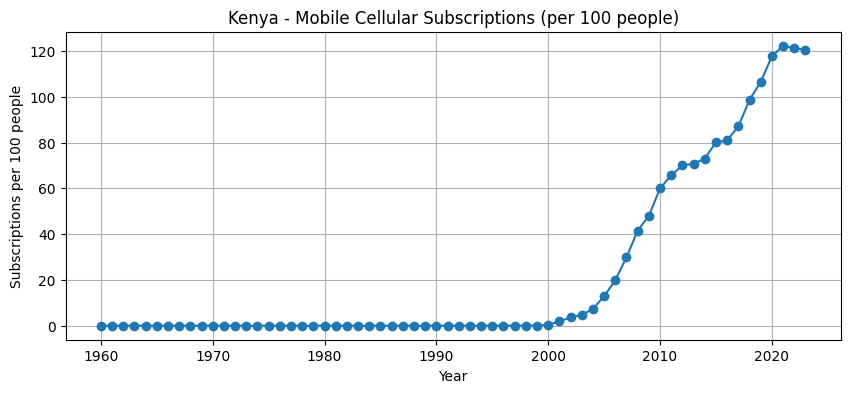

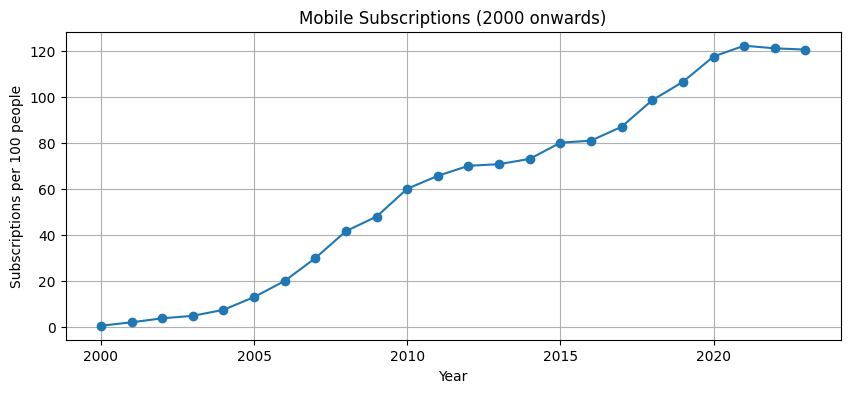

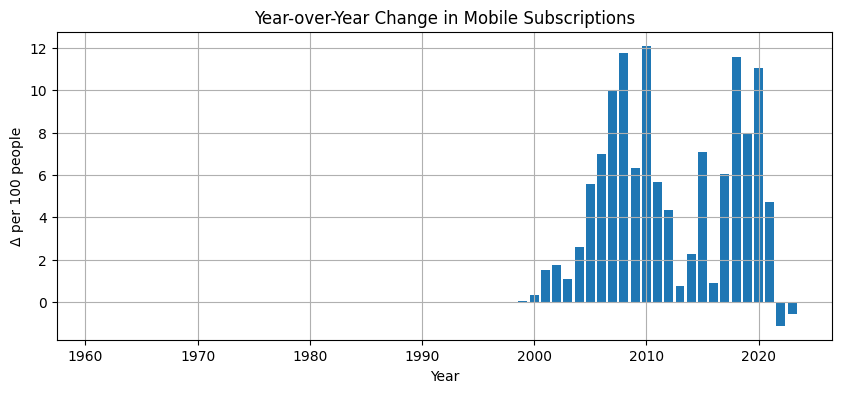

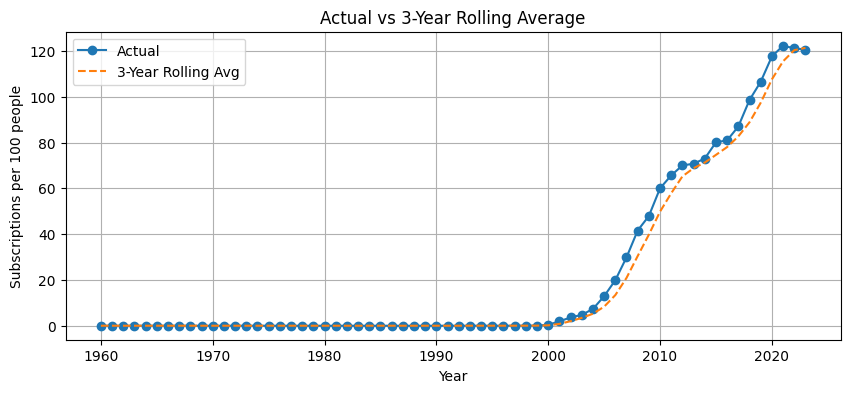

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sheet = "Sheet1"  # from the preview above
df = pd.read_excel(fname, sheet_name=sheet, header=0, engine="openpyxl")

# Clean names
df.columns = (df.columns.astype(str).str.strip().str.lower()
              .str.replace(r"\s+", "_", regex=True)
              .str.replace(r"[^0-9a-zA-Z_]+", "", regex=True))

# Set columns explicitly (we know them now)
date_col = "observation_date"
value_col = "itcelsetsp2ken"

# Parse types
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
df = df.dropna(subset=[date_col, value_col]).sort_values(date_col).reset_index(drop=True)
df["year"] = df[date_col].dt.year

# 1) Full line chart
plt.figure(figsize=(10,4))
plt.plot(df["year"], df[value_col], marker="o")
plt.title("Kenya - Mobile Cellular Subscriptions (per 100 people)")
plt.xlabel("Year"); plt.ylabel("Subscriptions per 100 people"); plt.grid(True)
plt.show()

# 2) Zoomed line chart (from 2000)
df_zoom = df[df["year"] >= 2000]
plt.figure(figsize=(10,4))
plt.plot(df_zoom["year"], df_zoom[value_col], marker="o")
plt.title("Mobile Subscriptions (2000 onwards)")
plt.xlabel("Year"); plt.ylabel("Subscriptions per 100 people"); plt.grid(True)
plt.show()

# 3) YoY change
df["yoy_change"] = df[value_col].diff()
plt.figure(figsize=(10,4))
plt.bar(df["year"], df["yoy_change"])
plt.title("Year-over-Year Change in Mobile Subscriptions")
plt.xlabel("Year"); plt.ylabel("Δ per 100 people"); plt.grid(True)
plt.show()

# 4) Actual vs 3-year rolling average
df["roll3"] = df[value_col].rolling(3, min_periods=1).mean()
plt.figure(figsize=(10,4))
plt.plot(df["year"], df[value_col], marker="o", label="Actual")
plt.plot(df["year"], df["roll3"], linestyle="--", label="3-Year Rolling Avg")
plt.title("Actual vs 3-Year Rolling Average")
plt.xlabel("Year"); plt.ylabel("Subscriptions per 100 people"); plt.legend(); plt.grid(True)
plt.show()
